<a href="https://colab.research.google.com/github/sharvari021/EDA_Process_on_Marketing_campaign_Dataset_Task04/blob/main/Task04_EDA_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Marketing campaign dataset.csv to Marketing campaign dataset.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='darkgrid')

print('Libraries ready!')

Libraries ready!


In [2]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

Saving Marketing campaign dataset.csv to Marketing campaign dataset.csv
Uploaded: Marketing campaign dataset.csv


In [3]:
df = pd.read_csv(filename)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (72612, 35)

Columns: ['campaign_item_id', 'no_of_days', 'time', 'ext_service_id', 'ext_service_name', 'creative_id', 'creative_width', 'creative_height', 'search_tags', 'template_id', 'landing_page', 'advertiser_id', 'advertiser_name', 'network_id', 'approved_budget', 'advertiser_currency', 'channel_id', 'channel_name', 'max_bid_cpm', 'network_margin', 'campaign_budget_usd', 'impressions', 'clicks', 'stats_currency', 'currency_code', 'exchange_rate', 'media_cost_usd', 'position_in_content', 'unique_reach', 'total_reach', 'search_tag_cat', 'cmi_currency_code', 'timezone', 'weekday_cat', 'keywords']

First 3 rows:


,campaign_item_id,no_of_days,time,ext_service_id,ext_service_name,creative_id,creative_width,creative_height,search_tags,template_id,...,exchange_rate,media_cost_usd,position_in_content,unique_reach,total_reach,search_tag_cat,cmi_currency_code,timezone,weekday_cat,keywords
0,2733,7,2022-05-01,128,Facebook Ads,1000,300.0,250.0,#The Power of X,90.0,...,1,14.058514,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_end,delicate bracelets
1,2733,8,2022-05-02,16,DV360,1000,300.0,250.0,#Be Bold. Be X,90.0,...,1,99.633496,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,summer jewelry
2,2733,9,2022-05-03,128,Facebook Ads,1000,300.0,250.0,#Embrace Your Individuality with X,90.0,...,1,109.419677,NaN,NaN,NaN,Others,SGD,Asia/Singapore,week_day,artisan jewelry


In [4]:
print('Missing values:')
print(df.isnull().sum())

print('\nData types:')
print(df.dtypes)

print('\nImpressions sample:', df['impressions'].head(10).tolist())
print('Clicks sample:',      df['clicks'].head(10).tolist())
print('\nImpression sum (raw):', df['impressions'].sum())
print('Clicks sum (raw):',      df['clicks'].sum())

Missing values:
campaign_item_id           0
no_of_days                 0
time                       0
ext_service_id             0
ext_service_name           0
creative_id                0
creative_width          3412
creative_height         3412
search_tags                0
template_id             3412
landing_page               0
advertiser_id              0
advertiser_name            0
network_id                 0
approved_budget          406
advertiser_currency        0
channel_id                 0
channel_name               0
max_bid_cpm            65206
network_margin             0
campaign_budget_usd        0
impressions                0
clicks                     0
stats_currency             0
currency_code              0
exchange_rate              0
media_cost_usd             0
position_in_content    72612
unique_reach           72612
total_reach            72612
search_tag_cat             0
cmi_currency_code          0
timezone                   0
weekday_cat                

In [5]:

df = df.drop_duplicates()


numeric_cols = ['impressions', 'clicks', 'media_cost_usd',
                'approved_budget', 'unique_reach', 'total_reach',
                'max_bid_cpm', 'campaign_budget_usd', 'exchange_rate']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

print('Cleaning done!')
print('Shape after cleaning:', df.shape)
print('\nImpression sum (after clean):', df['impressions'].sum())
print('Clicks sum (after clean):',      df['clicks'].sum())

Cleaning done!
Shape after cleaning: (72612, 35)

Impression sum (after clean): 99490192
Clicks sum (after clean): 3826390


In [6]:
CHANNEL_COL = 'ext_service_name'
SPEND_COL   = 'media_cost_usd'
REVENUE_COL = 'approved_budget'
IMPRESSIONS = 'impressions'
CLICKS_COL  = 'clicks'

# Add calculated columns
df['ctr'] = (df[CLICKS_COL] / df[IMPRESSIONS].replace(0, np.nan)) * 100
df['cpc'] = df[SPEND_COL] / df[CLICKS_COL].replace(0, np.nan)
df['roi'] = ((df[REVENUE_COL] - df[SPEND_COL]) / df[SPEND_COL].replace(0, np.nan)) * 100

print('Column mapping set!')
print('\nChannels found:')
print(df[CHANNEL_COL].value_counts())

Column mapping set!

Channels found:
ext_service_name
Facebook Ads    24275
DV360           24171
Google Ads      24166
Name: count, dtype: int64


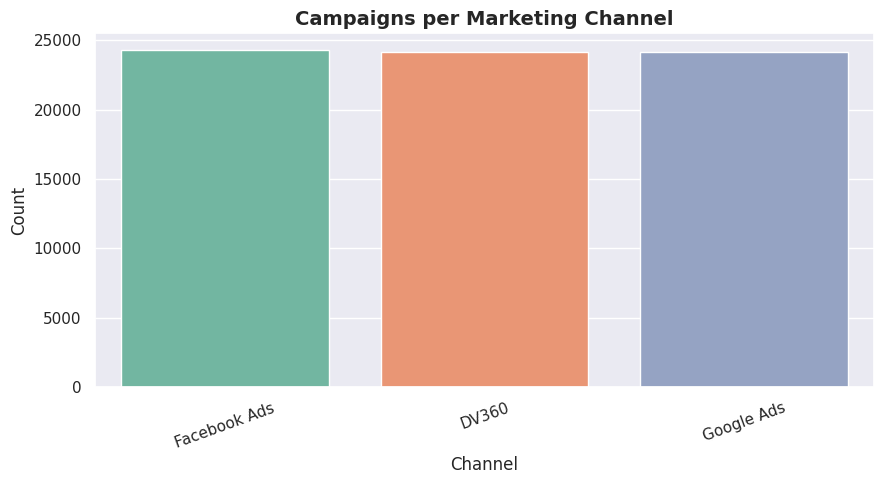

In [7]:
plt.figure(figsize=(9, 5))
channel_counts = df[CHANNEL_COL].value_counts()
sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Set2')
plt.title('Campaigns per Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart1_channel_distribution.png', dpi=150)
plt.show()

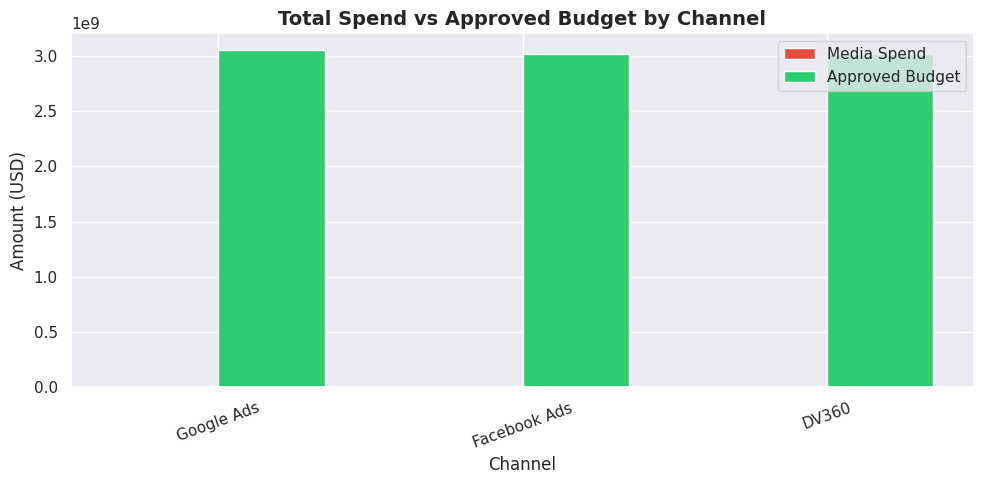

  ext_service_name  media_cost_usd  approved_budget
2       Google Ads   276479.747505     3.053299e+09
1     Facebook Ads   292018.285772     3.019106e+09
0            DV360   289775.718611     3.015633e+09


In [8]:
summary = df.groupby(CHANNEL_COL)[[SPEND_COL, REVENUE_COL]].sum().reset_index()
summary = summary.sort_values(REVENUE_COL, ascending=False)

x = np.arange(len(summary[CHANNEL_COL]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, summary[SPEND_COL],   width, label='Media Spend',      color='#e74c3c')
ax.bar(x + width/2, summary[REVENUE_COL], width, label='Approved Budget',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(summary[CHANNEL_COL], rotation=20)
ax.set_title('Total Spend vs Approved Budget by Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Amount (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_spend_vs_budget.png', dpi=150)
plt.show()
print(summary)

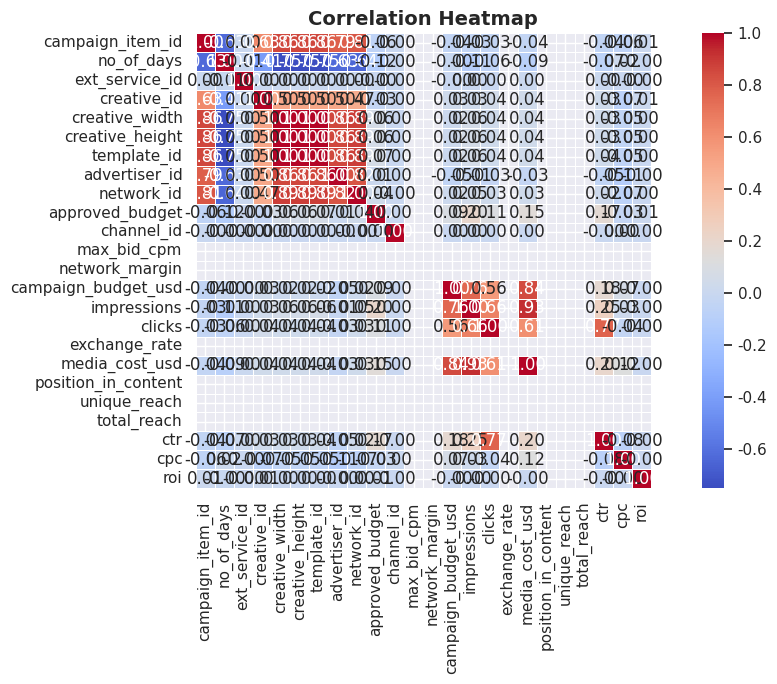

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(11, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150)
plt.show()

Impressions : 99,490,192
Clicks      : 3,826,390


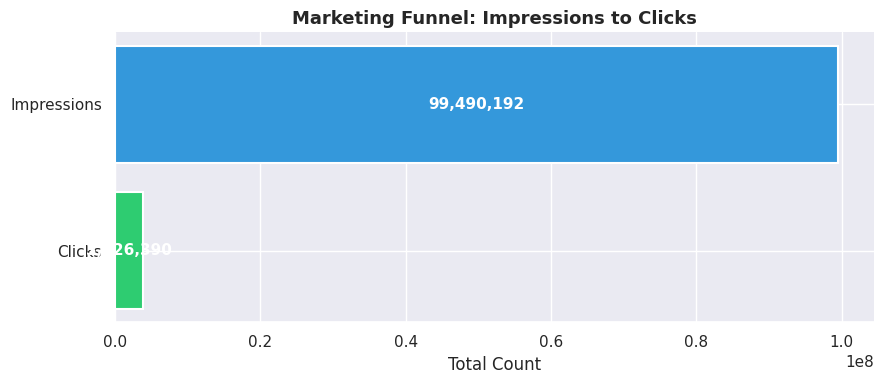


Overall CTR : 3.8460%
Drop-off    : 96.15%


In [10]:
total_imp    = int(df[IMPRESSIONS].sum())
total_clicks = int(df[CLICKS_COL].sum())

print(f'Impressions : {total_imp:,}')
print(f'Clicks      : {total_clicks:,}')

funnel_stages = ['Impressions', 'Clicks']
funnel_values = [total_imp, total_clicks]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3498db', '#2ecc71']
bars = ax.barh(funnel_stages[::-1], funnel_values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, funnel_values[::-1]):
    ax.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_title('Marketing Funnel: Impressions to Clicks', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_funnel.png', dpi=150)
plt.show()

if total_imp > 0:
    ctr = (total_clicks / total_imp) * 100
    print(f'\nOverall CTR : {ctr:.4f}%')
    print(f'Drop-off    : {100 - ctr:.2f}%')

ext_service_name   Total_Spend  Total_Budget  Total_Impr  Total_Clicks  Avg_CTR  Avg_CPC  Campaigns      ROI_%
      Google Ads 276479.747505  3.053299e+09    32336796       1180958 1.719946 0.401955      24166 1104248.24
           DV360 289775.718611  3.015633e+09    33702176       1345728 1.761735 0.404199      24171 1040578.31
    Facebook Ads 292018.285772  3.019106e+09    33451220       1299704 1.753345 0.399761      24275 1033775.64


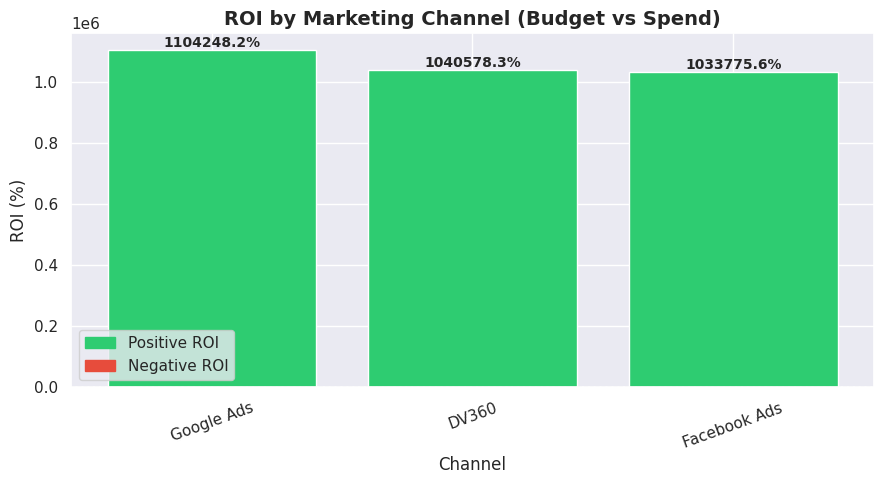

In [11]:
roi_summary = df.groupby(CHANNEL_COL).agg(
    Total_Spend      = (SPEND_COL,   'sum'),
    Total_Budget     = (REVENUE_COL, 'sum'),
    Total_Impr       = (IMPRESSIONS, 'sum'),
    Total_Clicks     = (CLICKS_COL,  'sum'),
    Avg_CTR          = ('ctr',       'mean'),
    Avg_CPC          = ('cpc',       'mean'),
    Campaigns        = (SPEND_COL,   'count')
).reset_index()

roi_summary['ROI_%'] = (
    (roi_summary['Total_Budget'] - roi_summary['Total_Spend'])
    / roi_summary['Total_Spend'] * 100
).round(2)

roi_summary = roi_summary.sort_values('ROI_%', ascending=False)
print(roi_summary.to_string(index=False))

# Plot
palette = ['#2ecc71' if r > 0 else '#e74c3c' for r in roi_summary['ROI_%']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(roi_summary[CHANNEL_COL], roi_summary['ROI_%'],
              color=palette, edgecolor='white')

for bar, val in zip(bars, roi_summary['ROI_%']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('ROI by Marketing Channel (Budget vs Spend)', fontsize=14, fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('ROI (%)')
ax.set_xticklabels(roi_summary[CHANNEL_COL], rotation=20)
green_p = mpatches.Patch(color='#2ecc71', label='Positive ROI')
red_p   = mpatches.Patch(color='#e74c3c', label='Negative ROI')
ax.legend(handles=[green_p, red_p])
plt.tight_layout()
plt.savefig('chart5_roi.png', dpi=150)
plt.show()

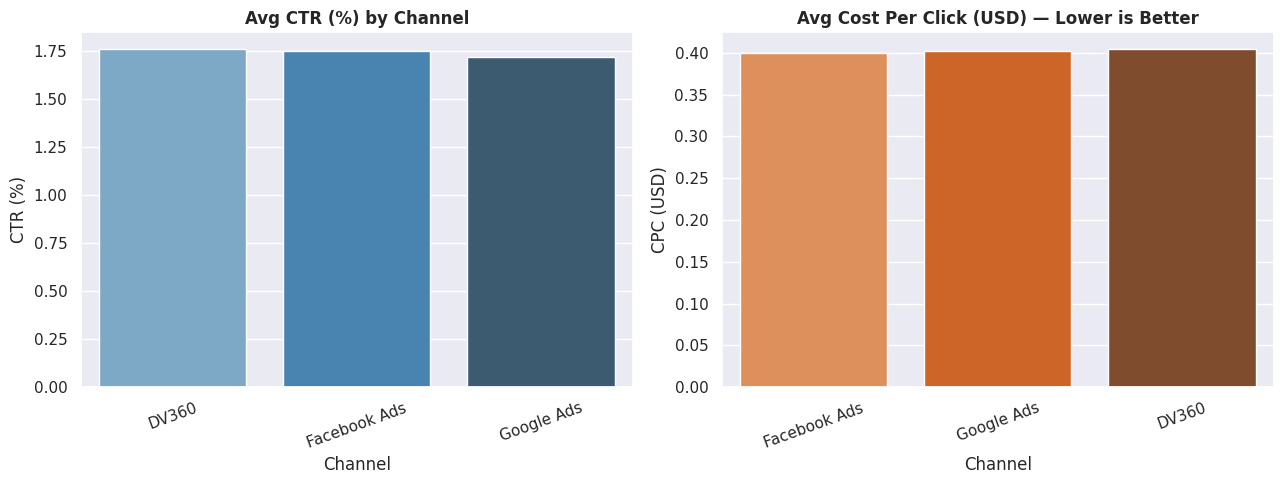

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ctr_data = roi_summary.sort_values('Avg_CTR', ascending=False)
sns.barplot(data=ctr_data, x=CHANNEL_COL, y='Avg_CTR',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Avg CTR (%) by Channel', fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('CTR (%)')
axes[0].tick_params(axis='x', rotation=20)

cpc_data = roi_summary.sort_values('Avg_CPC')
sns.barplot(data=cpc_data, x=CHANNEL_COL, y='Avg_CPC',
            palette='Oranges_d', ax=axes[1])
axes[1].set_title('Avg Cost Per Click (USD) — Lower is Better', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('CPC (USD)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart6_ctr_cpc.png', dpi=150)
plt.show()

In [13]:
best_ch   = roi_summary.iloc[0][CHANNEL_COL]
best_roi  = roi_summary.iloc[0]['ROI_%']
worst_ch  = roi_summary.iloc[-1][CHANNEL_COL]
worst_roi = roi_summary.iloc[-1]['ROI_%']
best_ctr  = roi_summary.sort_values('Avg_CTR', ascending=False).iloc[0][CHANNEL_COL]
best_cpc  = roi_summary.sort_values('Avg_CPC').iloc[0][CHANNEL_COL]

total_spend  = df[SPEND_COL].sum()
total_budget = df[REVENUE_COL].sum()
total_impr   = df[IMPRESSIONS].sum()
total_clicks = df[CLICKS_COL].sum()
overall_ctr  = (total_clicks / total_impr * 100) if total_impr > 0 else 0

report = f"""

     BUSINESS INSIGHTS REPORT - MARKETING EDA


CHANNELS : {', '.join(df[CHANNEL_COL].unique())}


OVERALL PERFORMANCE:-
  Total Media Spend     : ${total_spend:,.2f}
  Total Approved Budget : ${total_budget:,.2f}
  Total Impressions     : {total_impr:,}
  Total Clicks          : {total_clicks:,}
  Overall CTR           : {overall_ctr:.4f}%
  Total Records         : {len(df):,}


KEY FINDINGS:-
  Best ROI Channel    : {best_ch} ({best_roi:.1f}%)
  Worst ROI Channel   : {worst_ch} ({worst_roi:.1f}%)
  Best CTR Channel    : {best_ctr}
  Lowest CPC Channel  : {best_cpc}

  Channel Breakdown:
{roi_summary[[CHANNEL_COL,'Total_Spend','Total_Clicks','Avg_CTR','ROI_%']].to_string(index=False)}


FUNNEL INSIGHTS:-
  Impressions  : {total_impr:,}
  Clicks       : {total_clicks:,}
  Overall CTR  : {overall_ctr:.4f}%


BUDGET RECOMMENDATIONS:-
  1. INCREASE BUDGET  -> {best_ch}
     Reason: Highest ROI of {best_roi:.1f}%

  2. REVIEW & OPTIMIZE -> Mid-performing channels
     Action: A/B test creatives, refine targeting

  3. REDUCE / PAUSE   -> {worst_ch}
     Reason: Lowest ROI of {worst_roi:.1f}%

CONCLUSION:-
  Reallocate budget from {worst_ch} to {best_ch}.
  Focus on improving CTR through better ad creatives.
  Use weekday_cat column for time-based optimization.

  Prepared by: Sharvari | Task 04 - EDA Report

"""

print(report)
with open('Business_Insights_Report.txt', 'w') as f:
    f.write(report)
print('Report saved!')



     BUSINESS INSIGHTS REPORT - MARKETING EDA


CHANNELS : Facebook Ads, DV360, Google Ads


OVERALL PERFORMANCE:-
  Total Media Spend     : $858,273.75
  Total Approved Budget : $9,088,038,213.46
  Total Impressions     : 99,490,192
  Total Clicks          : 3,826,390
  Overall CTR           : 3.8460%
  Total Records         : 72,612


KEY FINDINGS:-
  Best ROI Channel    : Google Ads (1104248.2%)
  Worst ROI Channel   : Facebook Ads (1033775.6%)
  Best CTR Channel    : DV360
  Lowest CPC Channel  : Facebook Ads

  Channel Breakdown:
ext_service_name   Total_Spend  Total_Clicks  Avg_CTR      ROI_%
      Google Ads 276479.747505       1180958 1.719946 1104248.24
           DV360 289775.718611       1345728 1.761735 1040578.31
    Facebook Ads 292018.285772       1299704 1.753345 1033775.64


FUNNEL INSIGHTS:-
  Impressions  : 99,490,192
  Clicks       : 3,826,390
  Overall CTR  : 3.8460%


BUDGET RECOMMENDATIONS:-
  1. INCREASE BUDGET  -> Google Ads
     Reason: Highest ROI of 110424

In [14]:
from google.colab import files
import os

output_files = [
    'Business_Insights_Report.txt',
    'chart1_channel_distribution.png',
    'chart2_spend_vs_budget.png',
    'chart3_heatmap.png',
    'chart4_funnel.png',
    'chart5_roi.png',
    'chart6_ctr_cpc.png'
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Skipped (not found): {f}')

print('\nAll done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Business_Insights_Report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: chart5_roi.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart6_ctr_cpc.png

All done!


             impressions   clicks  media_cost_usd
weekday_cat                                      
week_day        84930469  3299302   731021.446463
week_end        14559723   527088   127252.305425


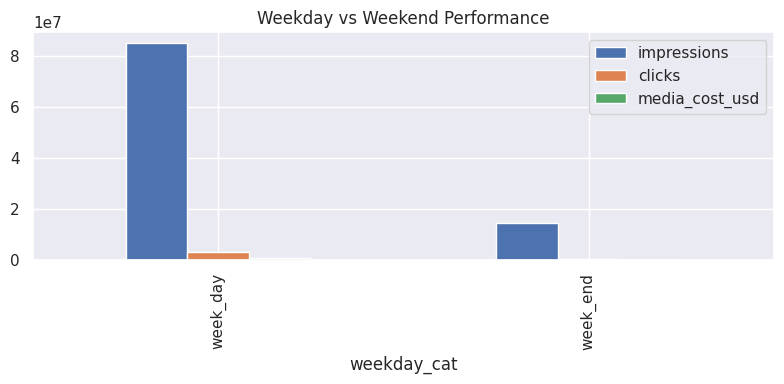

In [15]:
# Weekday vs Weekend performance
weekend = df.groupby('weekday_cat')[['impressions','clicks','media_cost_usd']].sum()
print(weekend)
weekend.plot(kind='bar', figsize=(8,4), title='Weekday vs Weekend Performance')
plt.tight_layout()
plt.show()